# Lesson 02 — Edges, gradients, and noise

Sobel gradients and Canny edges show where brightness changes and how image noise changes the result.

## Setup

Load a photograph and a controlled noisy edge scene.

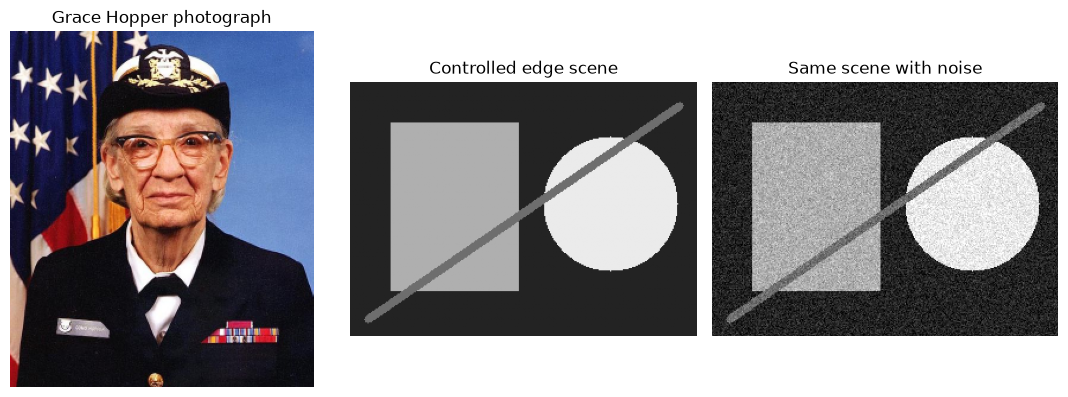

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\01-inputs.png
Repository root: C:\Users\Adity\Downloads\Official-Website-portfolio
Git branch: main
Results directory: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02
NumPy: 2.5.1
OpenCV: 5.0.0


In [2]:
from pathlib import Path
from time import perf_counter
import subprocess

import cv2
from matplotlib import cbook
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError(
        "No Git repository root was found. The notebook must run inside "
        "the assigned repository."
    )


def normalize_u8(image):
    return cv2.normalize(
        np.asarray(image, dtype=np.float32),
        None,
        0,
        255,
        cv2.NORM_MINMAX,
    ).astype(np.uint8)


def plot_image(axis, image, title, display="gray"):
    image_array = np.asarray(image)
    if display == "rgb":
        axis.imshow(image_array)
    elif display == "signed":
        scale = max(float(np.percentile(np.abs(image_array), 99)), 1.0)
        axis.imshow(
            image_array,
            cmap="coolwarm",
            vmin=-scale,
            vmax=scale,
        )
    elif display == "change":
        upper = max(float(np.percentile(image_array, 99)), 1.0)
        axis.imshow(image_array, cmap="magma", vmin=0, vmax=upper)
    else:
        axis.imshow(image_array, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")


def save_figure(figure, filename):
    output_path = RESULTS_DIR / filename
    figure.tight_layout()
    figure.savefig(output_path, dpi=110, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    return output_path


def sobel_components(gray):
    image = np.asarray(gray, dtype=np.float32)
    gx = cv2.Sobel(
        image,
        cv2.CV_32F,
        1,
        0,
        ksize=3,
        borderType=cv2.BORDER_REFLECT_101,
    )
    gy = cv2.Sobel(
        image,
        cv2.CV_32F,
        0,
        1,
        ksize=3,
        borderType=cv2.BORDER_REFLECT_101,
    )
    return gx, gy


def make_edge_scene(height=220, width=300, seed=7):
    rng = np.random.default_rng(seed)
    image = np.full((height, width), 35, dtype=np.uint8)
    cv2.rectangle(image, (35, 35), (145, 180), 175, -1)
    cv2.circle(image, (225, 105), 58, 235, -1)
    cv2.line(image, (15, 205), (285, 20), 110, 5)
    noise = rng.normal(0, 18, image.shape)
    noisy = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return image, noisy


REPO_ROOT = find_repository_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / "lesson-02"
if REPO_ROOT not in RESULTS_DIR.parents:
    raise RuntimeError("Results directory is outside the repository")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BRANCH = subprocess.run(
    ["git", "branch", "--show-current"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

PHOTO_PATH = Path(cbook.get_sample_data("grace_hopper.jpg", asfileobj=False))
photo_bgr = cv2.imread(str(PHOTO_PATH), cv2.IMREAD_COLOR)
if photo_bgr is None:
    raise RuntimeError(f"OpenCV could not read the sample photo: {PHOTO_PATH}")
photo_bgr = cv2.resize(photo_bgr, (256, 300), interpolation=cv2.INTER_AREA)
photo_rgb = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2RGB)
photo_gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY)

clean_scene, noisy_scene = make_edge_scene()
vertical_step = np.full((160, 220), 35, dtype=np.uint8)
vertical_step[:, 110:] = 220
horizontal_step = np.full((160, 220), 35, dtype=np.uint8)
horizontal_step[80:, :] = 220

figure, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(axes[1], clean_scene, "Controlled edge scene")
plot_image(axes[2], noisy_scene, "Same scene with noise")
save_figure(figure, "01-inputs.png")

print("Repository root:", REPO_ROOT)
print("Git branch:", BRANCH or "(detached)")
print("Results directory:", RESULTS_DIR)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

## Horizontal and vertical gradients

Sobel produces Gx and Gy. Record which component will respond more strongly to a vertical brightness edge.

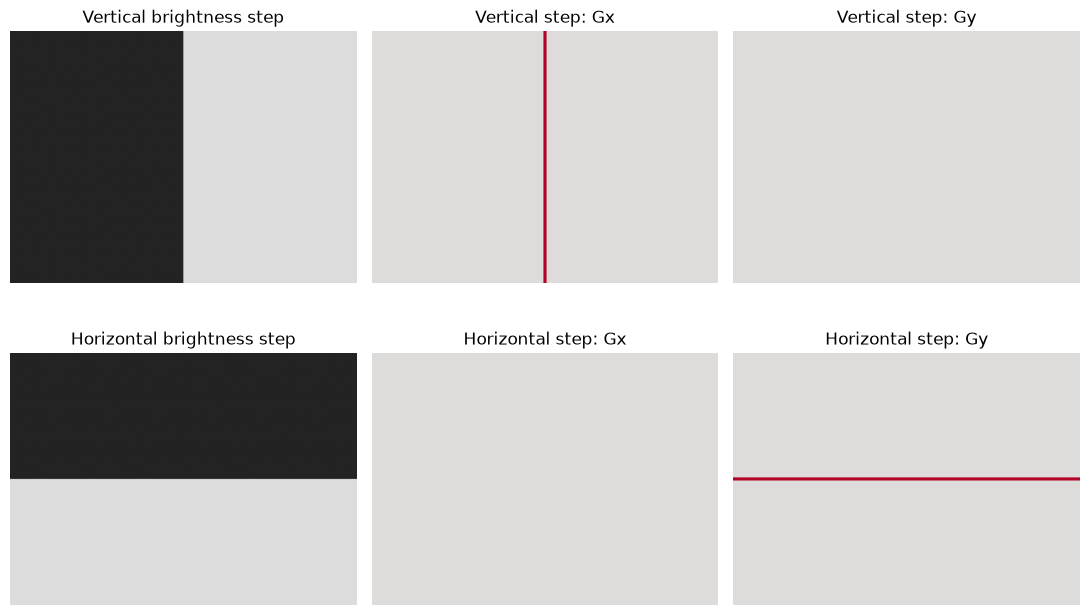

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\02-sobel-directions.png
Recorded prediction: Gx
Measured vertical-edge component: Gx
Vertical peaks, Gx and Gy: 740.0 0.0
Horizontal peaks, Gx and Gy: 0.0 740.0


In [5]:
prediction_vertical_component = 'Gx'
if prediction_vertical_component is None:
    raise RuntimeError("Record prediction_vertical_component before running this cell")

gx_vertical, gy_vertical = sobel_components(vertical_step)
gx_horizontal, gy_horizontal = sobel_components(horizontal_step)

vertical_gx_peak = float(np.max(np.abs(gx_vertical)))
vertical_gy_peak = float(np.max(np.abs(gy_vertical)))
horizontal_gx_peak = float(np.max(np.abs(gx_horizontal)))
horizontal_gy_peak = float(np.max(np.abs(gy_horizontal)))
measured_vertical_component = (
    "Gx" if vertical_gx_peak > vertical_gy_peak else "Gy"
)

assert vertical_gx_peak > 10 * max(vertical_gy_peak, 1.0)
assert horizontal_gy_peak > 10 * max(horizontal_gx_peak, 1.0)
DIRECTION_CHECKS_PASSED = True

figure, axes = plt.subplots(2, 3, figsize=(11, 7))
plot_image(axes[0, 0], vertical_step, "Vertical brightness step")
plot_image(axes[0, 1], gx_vertical, "Vertical step: Gx", display="signed")
plot_image(axes[0, 2], gy_vertical, "Vertical step: Gy", display="signed")
plot_image(axes[1, 0], horizontal_step, "Horizontal brightness step")
plot_image(axes[1, 1], gx_horizontal, "Horizontal step: Gx", display="signed")
plot_image(axes[1, 2], gy_horizontal, "Horizontal step: Gy", display="signed")
save_figure(figure, "02-sobel-directions.png")

print("Recorded prediction:", prediction_vertical_component)
print("Measured vertical-edge component:", measured_vertical_component)
print("Vertical peaks, Gx and Gy:", vertical_gx_peak, vertical_gy_peak)
print("Horizontal peaks, Gx and Gy:", horizontal_gx_peak, horizontal_gy_peak)

## Sign and strength

Reverse the brightness step. Predict whether the signed gradient will reverse while the gradient magnitude stays the same.

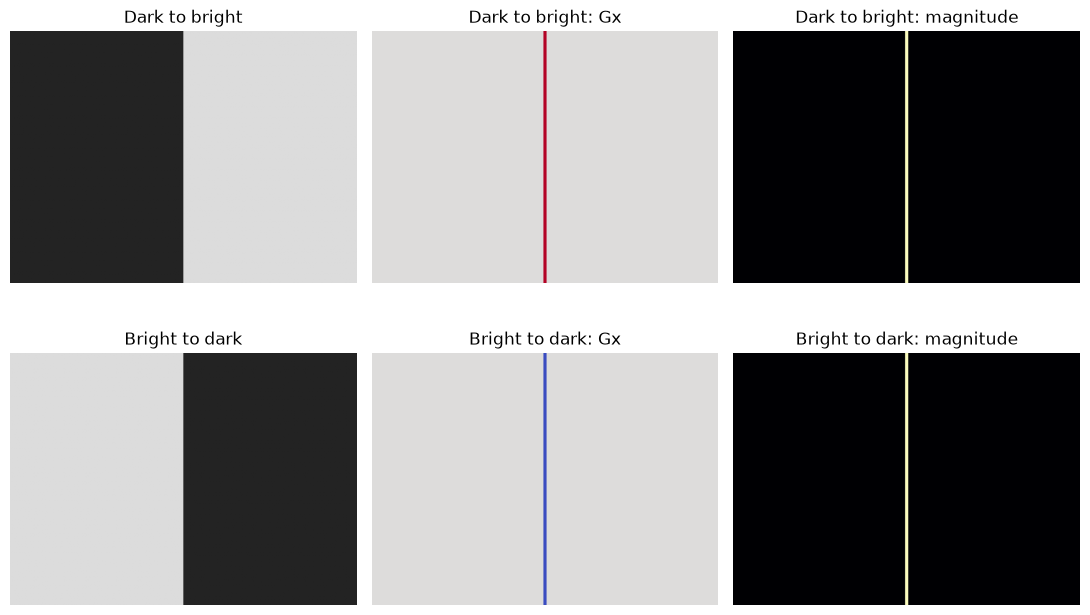

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\03-polarity-and-magnitude.png
Recorded prediction: True
Measured sign reversal: True
Maximum magnitude difference: 0.0


In [6]:
prediction_reversed_sign = True  # True or False
if prediction_reversed_sign is None:
    raise RuntimeError("Record prediction_reversed_sign before running this cell")

reversed_step = 255 - vertical_step
gx_forward, gy_forward = sobel_components(vertical_step)
gx_reversed, gy_reversed = sobel_components(reversed_step)
magnitude_forward = cv2.magnitude(gx_forward, gy_forward)
magnitude_reversed = cv2.magnitude(gx_reversed, gy_reversed)

edge_location = np.unravel_index(
    int(np.argmax(magnitude_forward)),
    magnitude_forward.shape,
)
forward_sign = int(np.sign(gx_forward[edge_location]))
reversed_sign = int(np.sign(gx_reversed[edge_location]))
magnitude_difference = float(
    np.max(np.abs(magnitude_forward - magnitude_reversed))
)
measured_reversed_sign = forward_sign == -reversed_sign

assert forward_sign != 0
assert measured_reversed_sign
assert magnitude_difference <= 1e-4
POLARITY_CHECKS_PASSED = True

figure, axes = plt.subplots(2, 3, figsize=(11, 7))
plot_image(axes[0, 0], vertical_step, "Dark to bright")
plot_image(axes[0, 1], gx_forward, "Dark to bright: Gx", display="signed")
plot_image(axes[0, 2], magnitude_forward, "Dark to bright: magnitude", display="change")
plot_image(axes[1, 0], reversed_step, "Bright to dark")
plot_image(axes[1, 1], gx_reversed, "Bright to dark: Gx", display="signed")
plot_image(axes[1, 2], magnitude_reversed, "Bright to dark: magnitude", display="change")
save_figure(figure, "03-polarity-and-magnitude.png")

print("Recorded prediction:", prediction_reversed_sign)
print("Measured sign reversal:", measured_reversed_sign)
print("Maximum magnitude difference:", magnitude_difference)

## Gradients in a photograph

Map horizontal change, vertical change, edge strength, and gradient direction in one image.

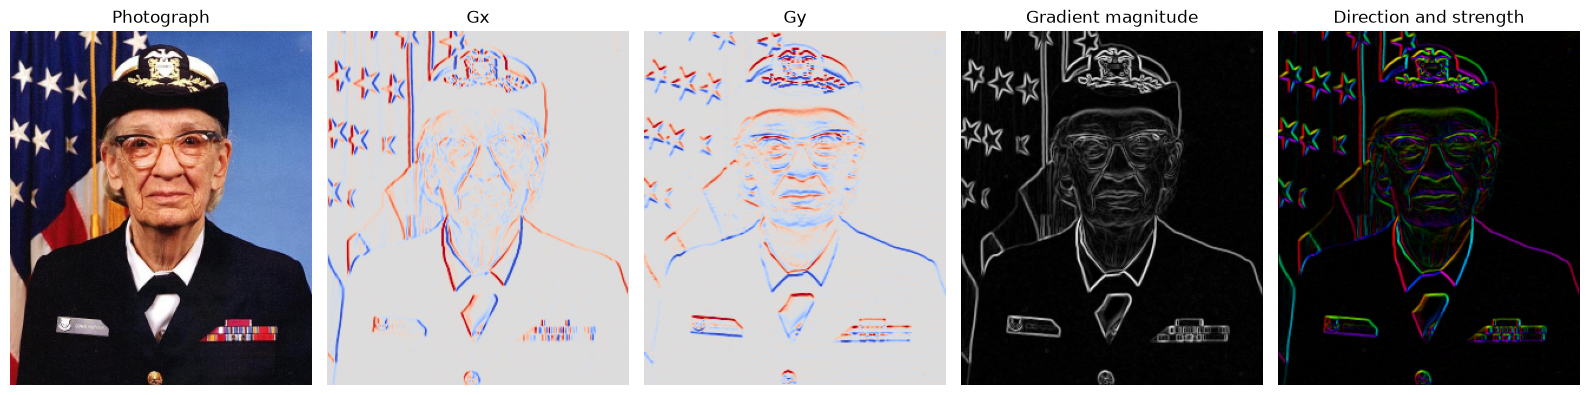

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\04-sobel-photo.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-02/04-sobel-photo.png')

In [7]:
gx_photo, gy_photo = sobel_components(photo_gray)
magnitude_photo = cv2.magnitude(gx_photo, gy_photo)
direction_photo = cv2.phase(gx_photo, gy_photo, angleInDegrees=True)
display_magnitude = normalize_u8(magnitude_photo)

hsv = np.zeros((*photo_gray.shape, 3), dtype=np.uint8)
hsv[..., 0] = np.mod(direction_photo / 2.0, 180).astype(np.uint8)
hsv[..., 1] = 255
hsv[..., 2] = display_magnitude
direction_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

figure, axes = plt.subplots(1, 5, figsize=(16, 4))
plot_image(axes[0], photo_rgb, "Photograph", display="rgb")
plot_image(axes[1], gx_photo, "Gx", display="signed")
plot_image(axes[2], gy_photo, "Gy", display="signed")
plot_image(axes[3], display_magnitude, "Gradient magnitude")
plot_image(axes[4], direction_rgb, "Direction and strength", display="rgb")
save_figure(figure, "04-sobel-photo.png")

## Noise before edge detection

Apply the same Canny thresholds before and after Gaussian smoothing. Predict how smoothing changes false edges.

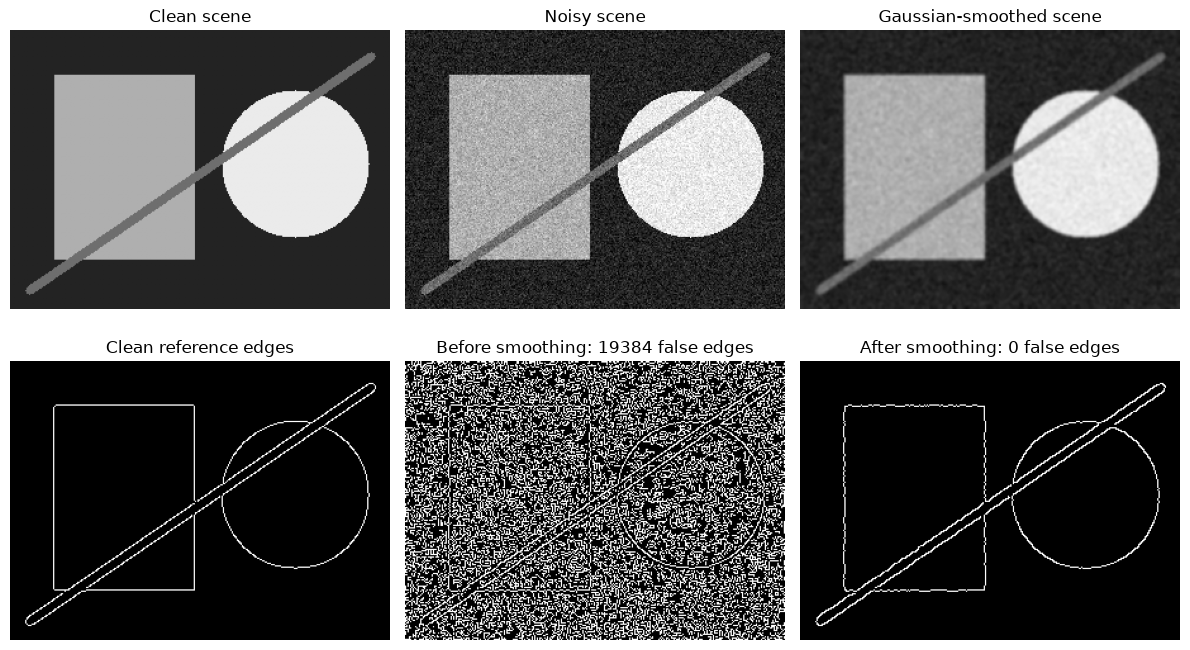

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\05-noise-and-smoothing.png
Recorded prediction: decrease
Measured effect: decrease
False edges before smoothing: 19384
False edges after smoothing: 0


In [8]:
prediction_smoothing_false_edges = "decrease"  # "increase", "decrease", or "same"
if prediction_smoothing_false_edges is None:
    raise RuntimeError(
        "Record prediction_smoothing_false_edges before running this cell"
    )

canny_low, canny_high = 60, 140
smoothed_scene = cv2.GaussianBlur(noisy_scene, (5, 5), 1.2)
clean_edges = cv2.Canny(clean_scene, canny_low, canny_high)
noisy_edges = cv2.Canny(noisy_scene, canny_low, canny_high)
smoothed_edges = cv2.Canny(smoothed_scene, canny_low, canny_high)

edge_support = cv2.dilate(
    clean_edges,
    np.ones((5, 5), dtype=np.uint8),
    iterations=1,
) > 0
false_edges_before = int(np.count_nonzero(noisy_edges[~edge_support]))
false_edges_after = int(np.count_nonzero(smoothed_edges[~edge_support]))
measured_smoothing_effect = (
    "decrease" if false_edges_after < false_edges_before else "increase"
)

assert false_edges_after < false_edges_before
NOISE_CHECKS_PASSED = True

figure, axes = plt.subplots(2, 3, figsize=(12, 7))
plot_image(axes[0, 0], clean_scene, "Clean scene")
plot_image(axes[0, 1], noisy_scene, "Noisy scene")
plot_image(axes[0, 2], smoothed_scene, "Gaussian-smoothed scene")
plot_image(axes[1, 0], clean_edges, "Clean reference edges")
plot_image(
    axes[1, 1],
    noisy_edges,
    f"Before smoothing: {false_edges_before} false edges",
)
plot_image(
    axes[1, 2],
    smoothed_edges,
    f"After smoothing: {false_edges_after} false edges",
)
save_figure(figure, "05-noise-and-smoothing.png")

print("Recorded prediction:", prediction_smoothing_false_edges)
print("Measured effect:", measured_smoothing_effect)
print("False edges before smoothing:", false_edges_before)
print("False edges after smoothing:", false_edges_after)

## Canny thresholds

Canny smooths the image, measures gradients, thins responses, applies two thresholds, and keeps weak edges connected to strong edges. Compare three threshold pairs on the photograph.

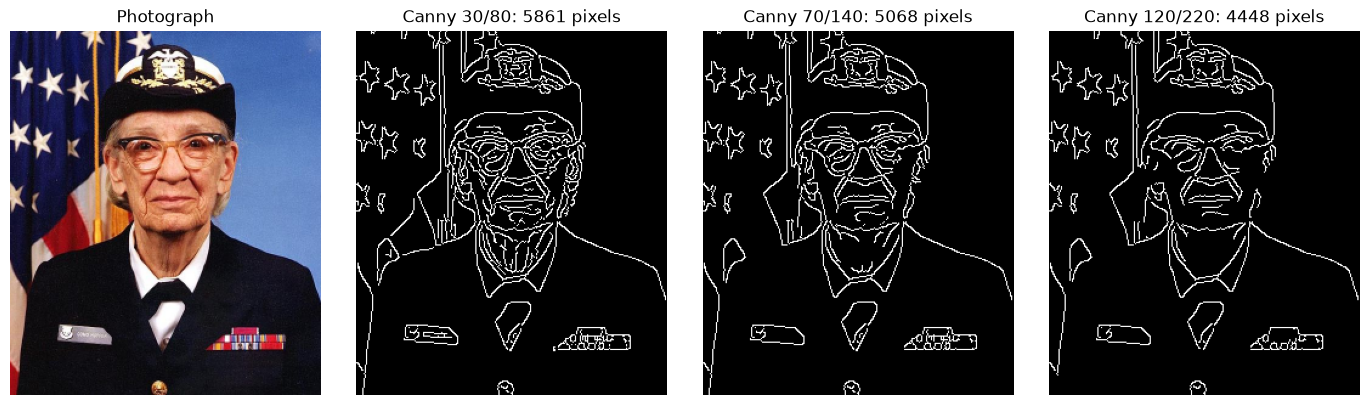

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\06-canny-thresholds.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-02/06-canny-thresholds.png')

In [9]:
photo_smoothed = cv2.GaussianBlur(photo_gray, (5, 5), 1.2)
threshold_pairs = [(30, 80), (70, 140), (120, 220)]
canny_results = [
    cv2.Canny(photo_smoothed, low, high)
    for low, high in threshold_pairs
]

figure, axes = plt.subplots(1, 4, figsize=(14, 4))
plot_image(axes[0], photo_rgb, "Photograph", display="rgb")
for axis, edges, pair in zip(axes[1:], canny_results, threshold_pairs):
    plot_image(
        axis,
        edges,
        f"Canny {pair[0]}/{pair[1]}: {np.count_nonzero(edges)} pixels",
    )
save_figure(figure, "06-canny-thresholds.png")

## Separable Gaussian filtering

Compare one 2-D Gaussian pass with horizontal and vertical one-dimensional passes.

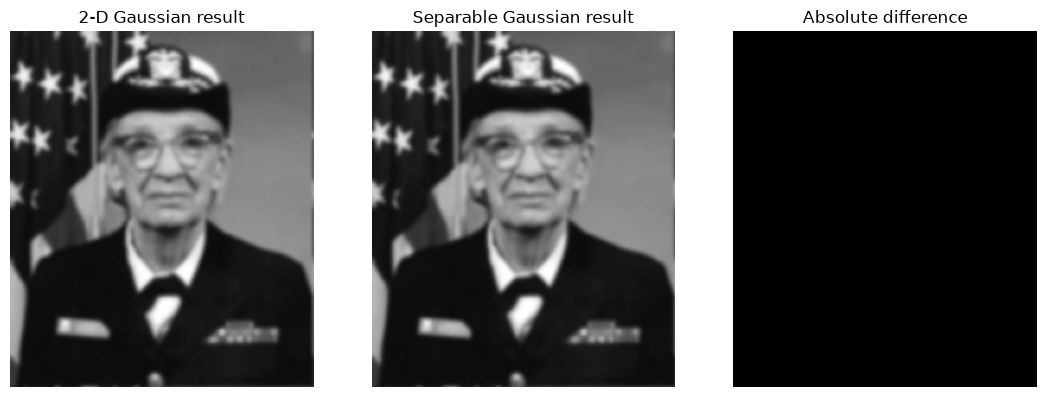

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-02\07-gaussian-separable.png
Maximum output difference: 6.103515625e-05
2-D Gaussian: 9.0863 ms
Separable Gaussian: 1.6373 ms


In [10]:
gaussian_1d = cv2.getGaussianKernel(9, 1.8, cv2.CV_32F)
gaussian_2d = gaussian_1d @ gaussian_1d.T
timing_image = np.tile(photo_gray, (3, 3))

direct_gaussian = cv2.filter2D(
    timing_image,
    cv2.CV_32F,
    gaussian_2d,
    borderType=cv2.BORDER_REFLECT_101,
)
separable_gaussian = cv2.sepFilter2D(
    timing_image,
    cv2.CV_32F,
    gaussian_1d,
    gaussian_1d,
    borderType=cv2.BORDER_REFLECT_101,
)
gaussian_difference = float(
    np.max(np.abs(direct_gaussian - separable_gaussian))
)

timing_repeats = 20
start = perf_counter()
for _ in range(timing_repeats):
    cv2.filter2D(
        timing_image,
        cv2.CV_32F,
        gaussian_2d,
        borderType=cv2.BORDER_REFLECT_101,
    )
direct_gaussian_ms = (perf_counter() - start) * 1000 / timing_repeats

start = perf_counter()
for _ in range(timing_repeats):
    cv2.sepFilter2D(
        timing_image,
        cv2.CV_32F,
        gaussian_1d,
        gaussian_1d,
        borderType=cv2.BORDER_REFLECT_101,
    )
separable_gaussian_ms = (perf_counter() - start) * 1000 / timing_repeats

assert gaussian_difference <= 1e-3
GAUSSIAN_CHECKS_PASSED = True

crop = (slice(0, 300), slice(0, 256))
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_image(axes[0], direct_gaussian[crop], "2-D Gaussian result")
plot_image(axes[1], separable_gaussian[crop], "Separable Gaussian result")
plot_image(
    axes[2],
    np.abs(direct_gaussian[crop] - separable_gaussian[crop]),
    "Absolute difference",
    display="change",
)
save_figure(figure, "07-gaussian-separable.png")

print("Maximum output difference:", gaussian_difference)
print(f"2-D Gaussian: {direct_gaussian_ms:.4f} ms")
print(f"Separable Gaussian: {separable_gaussian_ms:.4f} ms")

## Save measurements

Write predictions, edge counts, and Gaussian timings with the saved figures.

In [11]:
if not all(
    (
        DIRECTION_CHECKS_PASSED,
        POLARITY_CHECKS_PASSED,
        NOISE_CHECKS_PASSED,
        GAUSSIAN_CHECKS_PASSED,
    )
):
    raise RuntimeError("Lesson checks must pass before writing measurements")

expected_images = [
    "01-inputs.png",
    "02-sobel-directions.png",
    "03-polarity-and-magnitude.png",
    "04-sobel-photo.png",
    "05-noise-and-smoothing.png",
    "06-canny-thresholds.png",
    "07-gaussian-separable.png",
]
for image_name in expected_images:
    image_path = RESULTS_DIR / image_name
    if not image_path.is_file() or image_path.stat().st_size == 0:
        raise RuntimeError(f"Missing output image: {image_path}")

canny_measurements = "".join(
    f"canny_{low}_{high}_edge_pixels={np.count_nonzero(edges)}\n"
    for (low, high), edges in zip(threshold_pairs, canny_results)
)
measurements = (
    f"branch={BRANCH or '(detached)'}\n"
    f"numpy_version={np.__version__}\n"
    f"opencv_version={cv2.__version__}\n"
    f"prediction_vertical_component={prediction_vertical_component}\n"
    f"measured_vertical_component={measured_vertical_component}\n"
    f"prediction_reversed_sign={prediction_reversed_sign}\n"
    f"measured_reversed_sign={measured_reversed_sign}\n"
    f"prediction_smoothing_false_edges={prediction_smoothing_false_edges}\n"
    f"false_edges_before={false_edges_before}\n"
    f"false_edges_after={false_edges_after}\n"
    f"gaussian_max_difference={gaussian_difference:.8f}\n"
    f"direct_gaussian_ms={direct_gaussian_ms:.6f}\n"
    f"separable_gaussian_ms={separable_gaussian_ms:.6f}\n"
    f"timing_repeats={timing_repeats}\n"
    f"image_count={len(expected_images)}\n"
    + canny_measurements
)
(RESULTS_DIR / "measurements.txt").write_text(measurements, encoding="utf-8")
print(measurements)

branch=main
numpy_version=2.5.1
opencv_version=5.0.0
prediction_vertical_component=Gx
measured_vertical_component=Gx
prediction_reversed_sign=True
measured_reversed_sign=True
prediction_smoothing_false_edges=decrease
false_edges_before=19384
false_edges_after=0
gaussian_max_difference=0.00006104
direct_gaussian_ms=9.086320
separable_gaussian_ms=1.637305
timing_repeats=20
image_count=7
canny_30_80_edge_pixels=5861
canny_70_140_edge_pixels=5068
canny_120_220_edge_pixels=4448



## Questions

1. Why does a vertical brightness edge produce a large Gx response? Because moving horizontally detects changes vertically-edges that are vertical are detected in the Gx direction.
2. What information is lost when signed gradients become magnitude? The sign-we know the strength of the change but not what kind of change is happening (getting brighter or darker).
3. Why does Gaussian smoothing reduce false edges from noise? True edges are surrounded with pixels that are sharper (these standout more) and so the algorithm doesn't see them as a mistake or "noise," while false edges are like spikes in a flat plane-they standout and are averaged out with the surrounding pixels by the algorithm.
4. List the Canny stages and explain the connectivity step. A Canny algorithm smooths the image, measures its gradients, thins spikes, applies two thresholds, and keeps weak edges connected to strong edges. The connectivity step preservers contour in the image-it preserve weak edges that are near strong edges in order to discard noise but keep the tiny edges that still contribute to the image.
5. Why can a separable Gaussian filter match a full 2-D Gaussian filter? Because they both pass in the x and y directions-the separable does a pass in one direction and then in the other while the 2D works in both simultaneously.

Commit the executed notebook and `results/lesson-02/`, then push.

Sources: [OpenCV image gradients](https://docs.opencv.org/5.0/tutorials/imgproc/imgtrans/sobel_derivatives/sobel_derivatives.html) · [OpenCV Canny edge detection](https://docs.opencv.org/5.0/tutorials/imgproc/imgtrans/canny_detector/canny_detector.html)